In [3]:
import numpy as np
import networkx as nx
import time
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from numba import njit
from scipy.stats import gaussian_kde
from scipy.linalg import eigvals
from scipy.linalg import expm
from matplotlib import rc

rc('font',**{'family':'serif','serif':['Times New Roman']})
rc('text', usetex=True)

In [25]:
Estocastica = np.load('Estocastica/F_Estocastica_deltas.npy', allow_pickle=True).item()
Determinista1_Best = np.load('Determinista_1/F_Deterministic_deltar_Best.npy', allow_pickle=True).item()
Determinista1_Worst = np.load('Determinista_1/F_Deterministic_deltar_Worst.npy', allow_pickle=True).item()
Determinista2_Best = np.load('Determinista_2/F_Deterministic_deltar_enlace_Best.npy', allow_pickle=True).item()
Determinista2_Worst = np.load('Determinista_2/F_Deterministic_deltar_enlace_Worst.npy', allow_pickle=True).item()
Edge_B_High = np.load('Edge_B/F_edge_deltar_high_betweenness.npy', allow_pickle=True).item()
Edge_B_Low = np.load('Edge_B/F_edge_deltar_low_betweenness.npy', allow_pickle=True).item()
Edge_Ponderada_High = np.load('Edge_Ponderada/F_edge_deltar_high_betweenness.npy', allow_pickle=True).item()
Edge_Ponderada_Low = np.load('Edge_Ponderada/F_edge_deltar_low_betweenness.npy', allow_pickle=True).item()
Topo_Best = np.load('Topo_1/F_inter_first_best.npy', allow_pickle=True).item()
Topo_Worst = np.load('Topo_1/F_inter_first_worst.npy', allow_pickle=True).item()


In [53]:
# -----------------------------------DATOS--------------------------------------

datasets = {
    'Estocástica':           Estocastica,
    'Determinista 1 Best':   Determinista1_Best,
    'Determinista 1 Worst':  Determinista1_Worst,
    'Determinista 2 Best':   Determinista2_Best,
    'Determinista 2 Worst':  Determinista2_Worst,
    'Edge B High':           Edge_B_High,
    'Edge B Low':            Edge_B_Low,
    'Edge Ponderada High':   Edge_Ponderada_High,
    'Edge Ponderada Low':    Edge_Ponderada_Low,
    'Topo Best':             Topo_Best,
    'Topo Worst':            Topo_Worst,
}

estilos = {
    # Estocástica — referencia en negro sólido grueso
    'Estocástica':           dict(color='black',         linestyle='-',               linewidth=2.5, marker='None'),

    # Determinista 1 — azules (oscuro / claro)
    'Determinista 1 Best':   dict(color='#1a6faf',       linestyle='--',              linewidth=2.5, marker='o',  markersize=5, markevery=2000),
    'Determinista 1 Worst':  dict(color='#7ab8d9',       linestyle=':',               linewidth=2.5, marker='s',  markersize=5, markevery=2000),

    # Determinista 2 — rojos (oscuro / claro)
    'Determinista 2 Best':   dict(color='#c0392b',       linestyle='-.',              linewidth=2.5, marker='^',  markersize=5, markevery=2000),
    'Determinista 2 Worst':  dict(color='#f1948a',       linestyle=(0, (5,5)),        linewidth=2.5, marker='v',  markersize=5, markevery=2000),

    # Edge Betweenness — verdes (oscuro / claro)
    'Edge B High':           dict(color='#1e8449',       linestyle=(0, (1,1)),        linewidth=2.5, marker='D',  markersize=5, markevery=2000),
    'Edge B Low':            dict(color='#82c983',       linestyle=(0, (5,1,1,1)),    linewidth=2.5, marker='d',  markersize=5, markevery=2000),

    # Edge Ponderada — naranjas (oscuro / claro)
    'Edge Ponderada High':   dict(color='#d35400',       linestyle=(0, (3,5,1,5)),    linewidth=2.5, marker='P',  markersize=5, markevery=2000),
    'Edge Ponderada Low':    dict(color='#f0a868',       linestyle=(0, (1,5)),        linewidth=2.5, marker='X',  markersize=5, markevery=2000),

    # Topo — morados (oscuro / claro)
    'Topo Best':             dict(color='#6c3483',       linestyle=(0, (5,5)),        linewidth=2.5, marker='*',  markersize=6, markevery=2000),
    'Topo Worst':            dict(color='#c39bd3',       linestyle=(0, (3,1,1,1,1,1)),linewidth=2.5, marker='h',  markersize=6, markevery=2000),
}

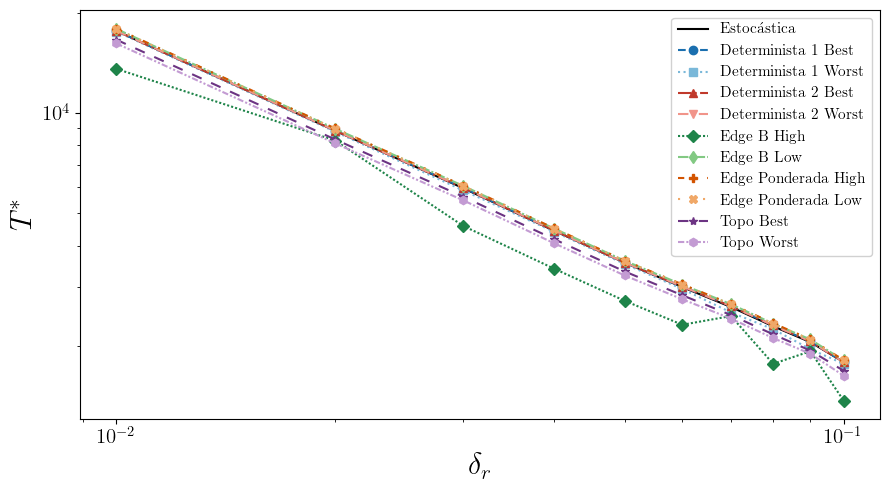

In [54]:
# -----------------------------------CÁLCULO T*--------------------------------------

umbral = 0.99

# Tomar las keys directamente del primer dataset (todas tienen las mismas)
deltas_r = np.array(sorted(Estocastica.keys()))

T_stars = {}

for nombre, data in datasets.items():
    keys = np.array(sorted(data.keys()))  # keys reales de cada dict
    T_stars[nombre] = []
    for key in keys:
        arr     = data[key]
        indices = np.where(arr >= umbral)[0]
        T_stars[nombre].append(indices[0] if len(indices) > 0 else np.nan)
    T_stars[nombre] = np.array(T_stars[nombre])

# -----------------------------------GRÁFICA--------------------------------------

fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')

for nombre, T_star in T_stars.items():
    est = estilos[nombre]
    ax.loglog(deltas_r, T_star,
            color=est['color'], marker=est['marker'], linestyle=est['linestyle'],
            linewidth=1.5, markersize=6, label=nombre)

ax.set_xlabel(r"$\delta_r$", fontsize=22)
ax.set_ylabel(r"$T^*$",      fontsize=22)
ax.tick_params(labelsize=15)
ax.legend(fontsize=11, framealpha=0.9, loc='best')
plt.tight_layout()
plt.show()

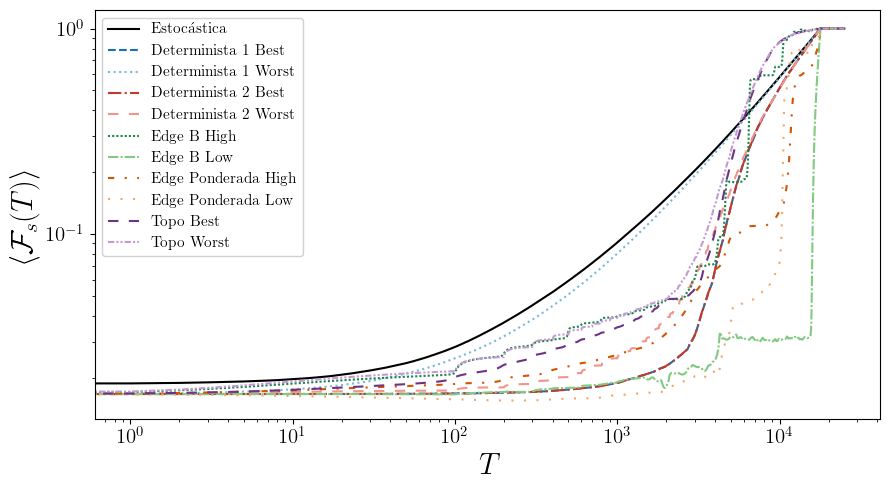

In [55]:
# --- PARÁMETROS ---
T_repair = 25000
delta_r  = 0.01

t_repair = np.arange(T_repair + 1)

# --- FIGURA ---
fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')

# --- CURVAS ---
for nombre, data in datasets.items():
    # Buscar la key más cercana a delta_r
    key = min(data.keys(), key=lambda k: abs(k - delta_r))
    est = estilos[nombre]
    ax.loglog(t_repair, data[key],
              color=est['color'], linestyle=est['linestyle'],
              linewidth=1.5, label=nombre)

# --- ETIQUETAS ---
ax.set_xlabel(r"$T$",                                        fontsize=22)
ax.set_ylabel(r"$\left\langle \mathcal{F}_s(T) \right\rangle$", fontsize=22)
ax.tick_params(labelsize=15)
ax.legend(fontsize=11, framealpha=0.9, loc='best')
plt.tight_layout()
plt.show()